# Smart ML System for Predictive Analysis of Student Performance

## 03 - Exploratory Data Analysis

This notebook explores the cleaned student performance dataset to identify patterns, distributions, relationships, and potential outliers.

The analysis focuses on:

- Understanding the distribution of student scores
- Analyzing study hours, attendance, and participation
- Investigating relationships between features and total score
- Identifying potential outliers
- Understanding feature relationships before machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

file_path = Path("../data/processed/student_performance_model_data.csv")

df = pd.read_csv(file_path)

df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
0,18.5,95.6,3.8,97.9
1,14.0,80.0,2.5,83.9
2,19.5,86.3,5.3,100.0
3,25.7,70.2,7.0,100.0
4,13.4,81.9,6.9,92.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   weekly_self_study_hours  5010 non-null   float64
 1   attendance_percentage    5010 non-null   float64
 2   class_participation      5010 non-null   float64
 3   total_score              5010 non-null   float64
dtypes: float64(4)
memory usage: 156.7 KB


In [4]:
df.describe()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,5010.000000,5010.000000,5010.000000,5010.000000
mean,15.075948,84.657984,5.992375,84.637166
std,6.867848,9.409866,1.964185,15.358746
min,0.000000,50.000000,0.000000,14.600000
25%,10.400000,78.200000,4.700000,74.700000
50%,15.100000,84.650000,6.000000,88.050000
75%,19.700000,91.700000,7.400000,100.000000
max,40.000000,100.000000,10.000000,100.000000


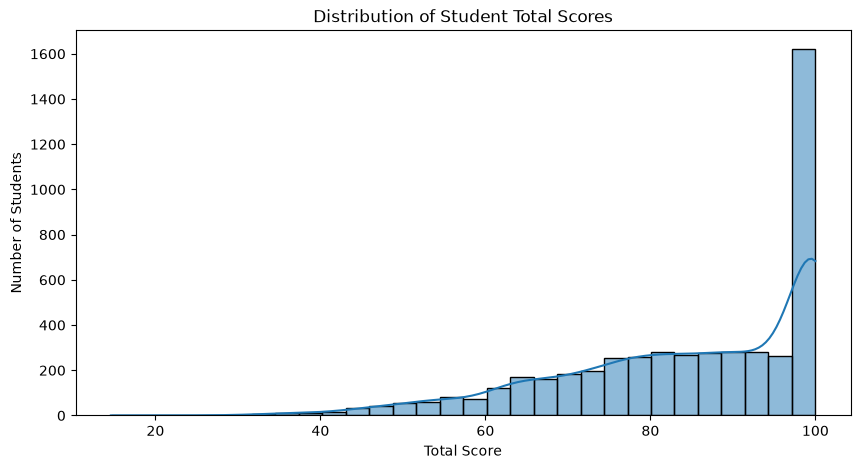

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["total_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Student Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.show()

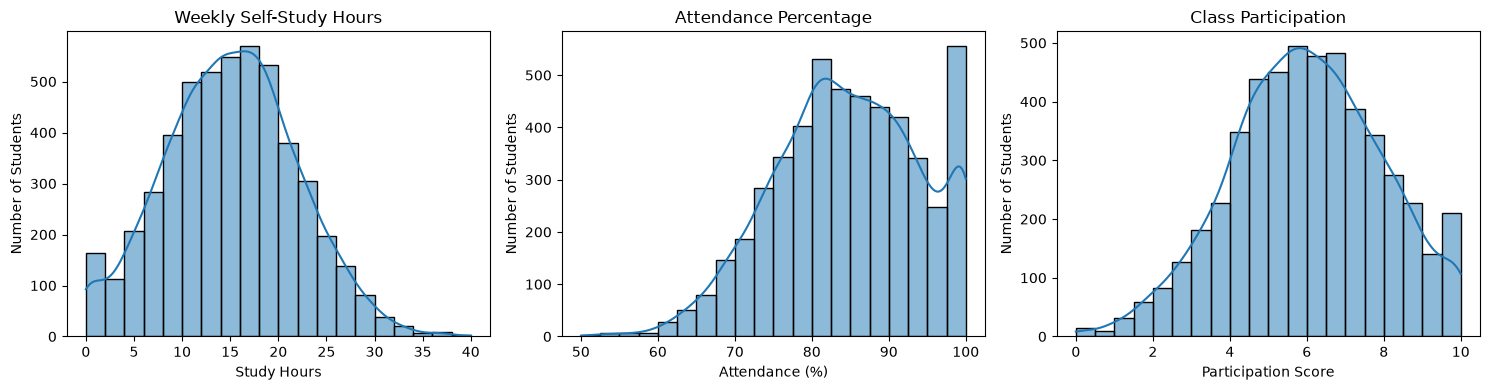

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["weekly_self_study_hours"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Weekly Self-Study Hours")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Number of Students")

sns.histplot(df["attendance_percentage"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Attendance Percentage")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Number of Students")

sns.histplot(df["class_participation"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Class Participation")
axes[2].set_xlabel("Participation Score")
axes[2].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


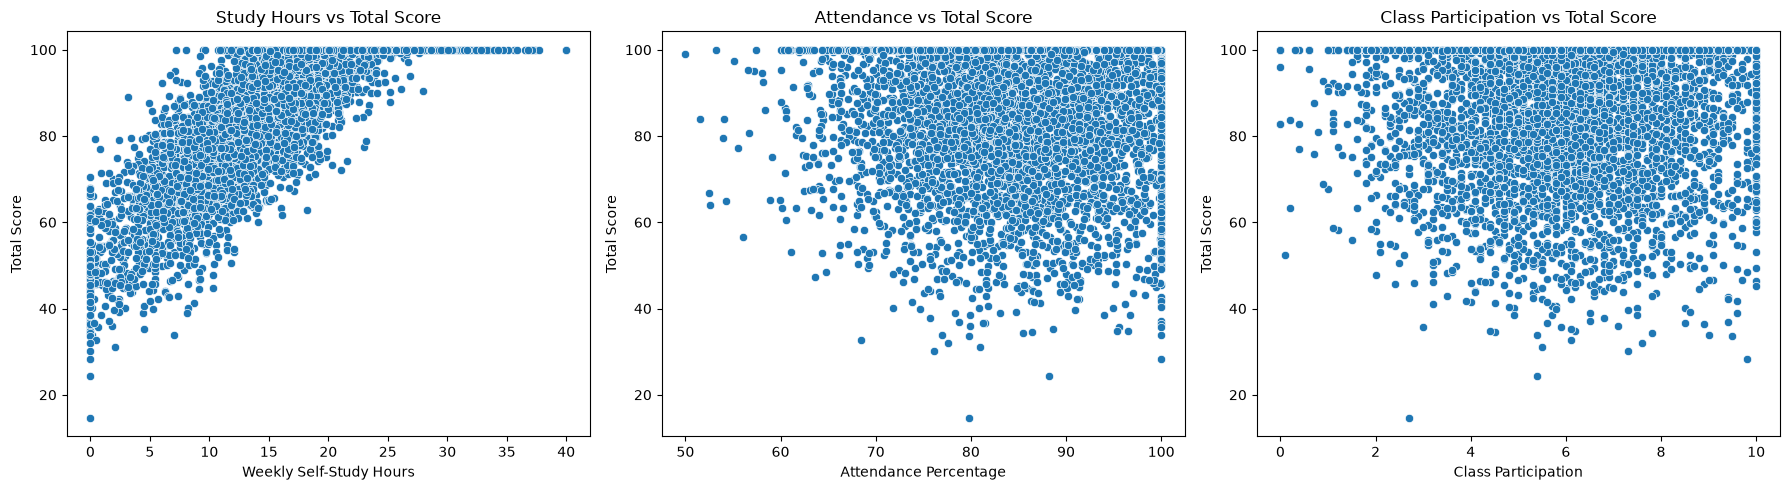

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x="weekly_self_study_hours",
    y="total_score",
    ax=axes[0]
)
axes[0].set_title("Study Hours vs Total Score")
axes[0].set_xlabel("Weekly Self-Study Hours")
axes[0].set_ylabel("Total Score")

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="total_score",
    ax=axes[1]
)
axes[1].set_title("Attendance vs Total Score")
axes[1].set_xlabel("Attendance Percentage")
axes[1].set_ylabel("Total Score")

sns.scatterplot(
    data=df,
    x="class_participation",
    y="total_score",
    ax=axes[2]
)
axes[2].set_title("Class Participation vs Total Score")
axes[2].set_xlabel("Class Participation")
axes[2].set_ylabel("Total Score")

plt.tight_layout()
plt.show()

In [8]:
correlation = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score"
    ]
].corr()

correlation

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.019163,-0.033600,0.809622
attendance_percentage,-0.019163,1.000000,-0.013619,-0.029022
class_participation,-0.033600,-0.013619,1.000000,-0.032842
total_score,0.809622,-0.029022,-0.032842,1.000000


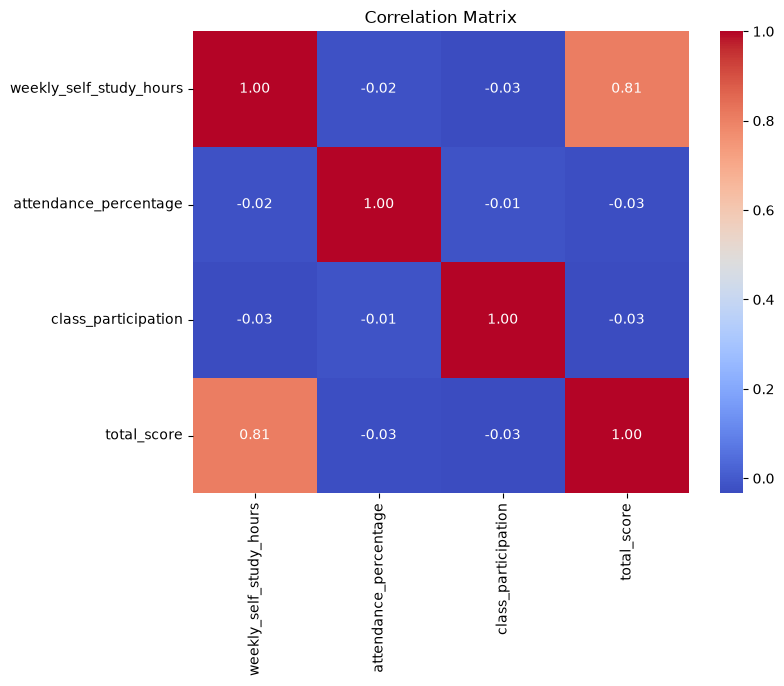

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

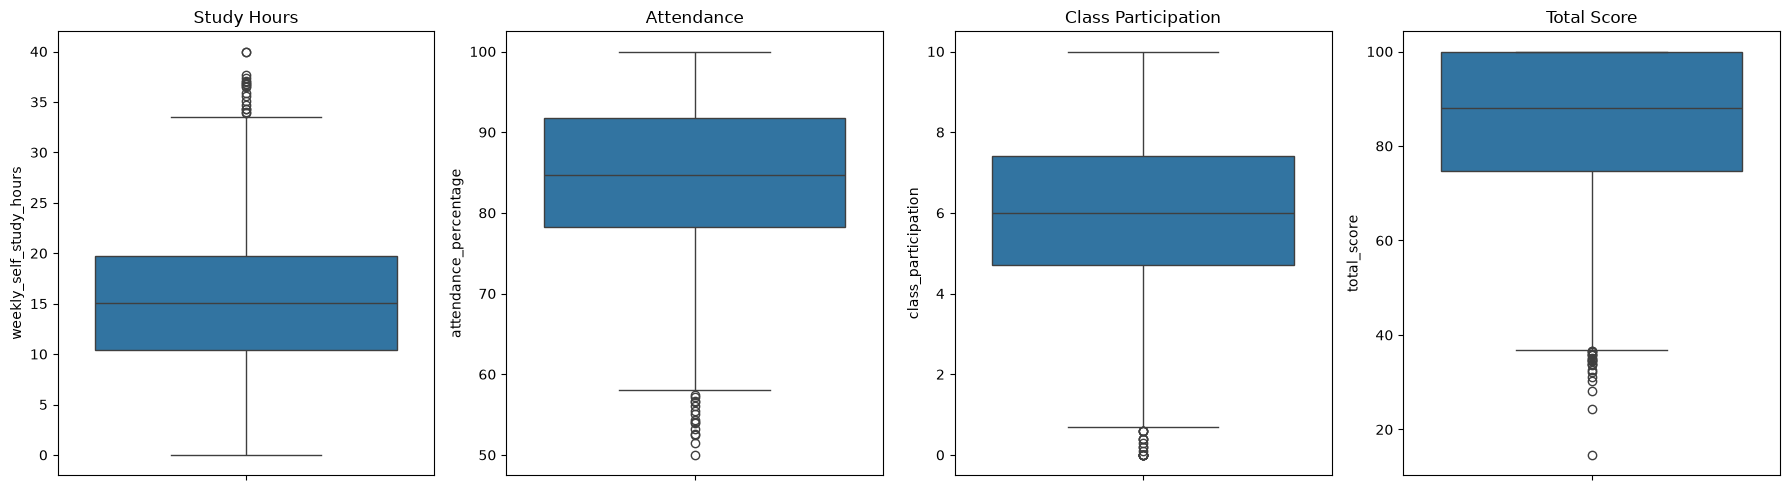

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(y=df["weekly_self_study_hours"], ax=axes[0])
axes[0].set_title("Study Hours")

sns.boxplot(y=df["attendance_percentage"], ax=axes[1])
axes[1].set_title("Attendance")

sns.boxplot(y=df["class_participation"], ax=axes[2])
axes[2].set_title("Class Participation")

sns.boxplot(y=df["total_score"], ax=axes[3])
axes[3].set_title("Total Score")

plt.tight_layout()
plt.show()

In [11]:
features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

df[features].corr()

,weekly_self_study_hours,attendance_percentage,class_participation
weekly_self_study_hours,1.000000,-0.019163,-0.033600
attendance_percentage,-0.019163,1.000000,-0.013619
class_participation,-0.033600,-0.013619,1.000000
